<a href="https://colab.research.google.com/github/Nobodybutyouu/FBD_detection_models/blob/main/FBD_detection_AlexNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import itertools

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report


In [ ]:
!cp -r "/content/drive/MyDrive/ricePlant_dataSet" "/content/"

train_dir = "/content/drive/MyDrive/ricePlant_dataSet/train"
test_dir  = "/content/drive/MyDrive/ricePlant_dataSet/test"

print("Dataset copied to local runtime")

Dataset copied to local runtime


In [ ]:
IMG_SIZE = 227        # AlexNet standard input size
BATCH_SIZE = 32
EPOCHS = 50

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',              # RGB for AlexNet
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Classes: ['Healthy_images', 'Unhealthy_images']


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

model = Sequential([

    # Layer 1
    Conv2D(96, kernel_size=(11,11), strides=4, activation='relu',
           input_shape=(227,227,3)),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 2
    Conv2D(256, kernel_size=(5,5), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    # Layer 3
    Conv2D(384, kernel_size=(3,3), padding='same', activation='relu'),

    # Layer 4
    Conv2D(384, kernel_size=(3,3), padding='same', activation='relu'),

    # Layer 5
    Conv2D(256, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=2),

    Flatten(),

    # Fully Connected Layers
    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(4096, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,289,538 (222.36 MB)

 Trainable params: 58,289,538 (222.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 194s 8s/step - accuracy: 0.5023 - loss: 2.6010 - val_accuracy: 0.5000 - val_loss: 0.6946
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 190s 8s/step - accuracy: 0.5079 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 189s 8s/step - accuracy: 0.4842 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.8483
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 183s 7s/step - accuracy: 0.5050 - loss: 0.7205 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 182s 7s/step - accuracy: 0.4693 - loss: 0.6947 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 180s 7s/step - accuracy: 0.4821 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 181s 7s/step - accuracy: 0.4596 - loss: 0.6945 - val_accuracy: 0.5000 - val_loss: 0.6932


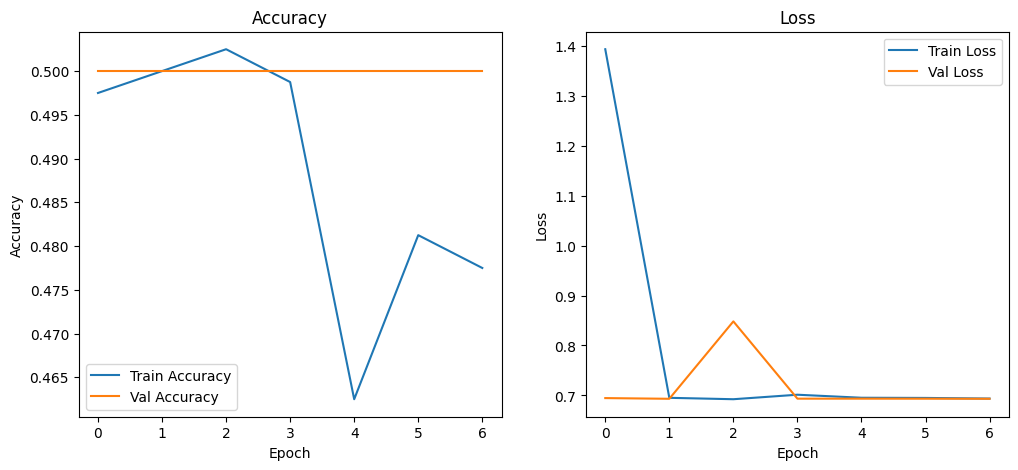

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
y_true = test_generator.classes

y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step


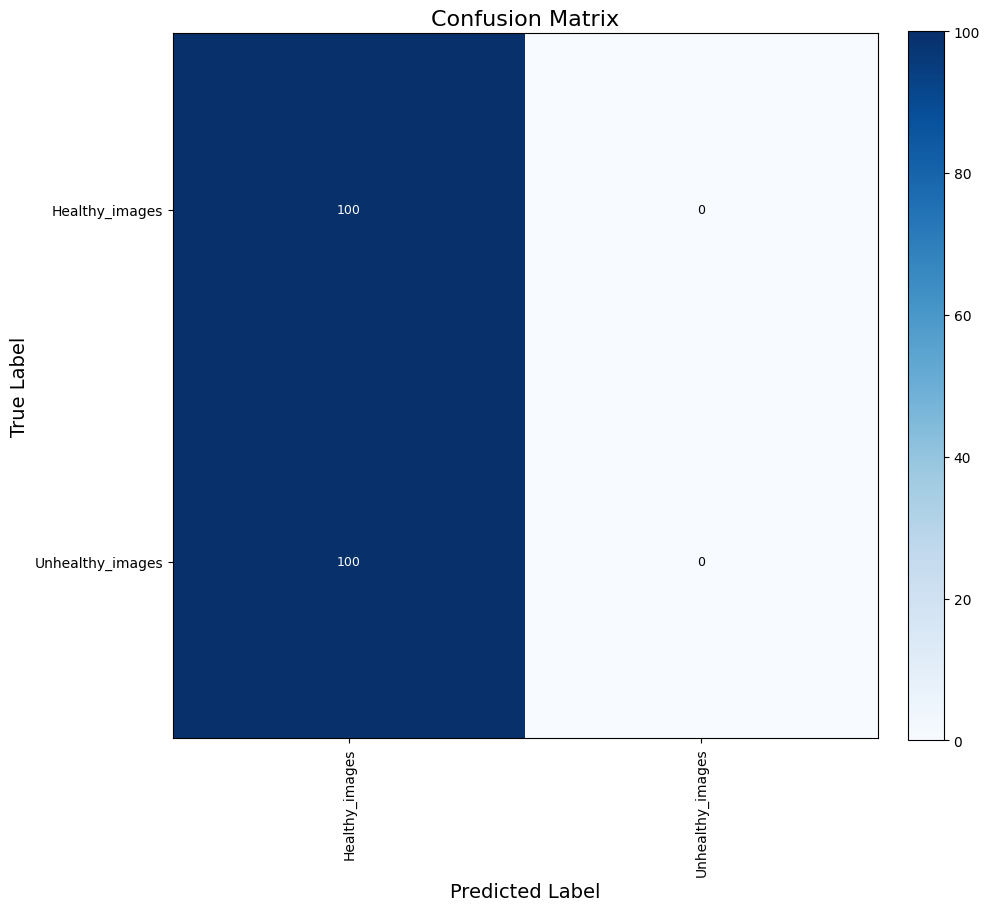

Classification Report:

                  precision    recall  f1-score   support

  Healthy_images     0.5000    1.0000    0.6667       100
Unhealthy_images     0.0000    0.0000    0.0000       100

        accuracy                         0.5000       200
       macro avg     0.2500    0.5000    0.3333       200
    weighted avg     0.2500    0.5000    0.3333       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def plot_confusion_matrix(cm, class_names):
    num_classes = len(class_names)

    fig_size = max(10, num_classes * 0.7)
    plt.figure(figsize=(fig_size, fig_size))

    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", fontsize=16)
    plt.colorbar(fraction=0.046, pad=0.04)

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, class_names, rotation=90, fontsize=10)
    plt.yticks(tick_marks, class_names, fontsize=10)

    thresh = cm.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(
                j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                fontsize=9,
                color="white" if cm[i, j] > thresh else "black"
            )

    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cm, class_names)

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)
